# Notebook 04 — Model Training & Evaluation

**Project**: Ethiopian Fintech Analytics Platform  
**Author**: Eyob Nebyou  
**Dataset**: Give Me Some Credit (feature store from Notebook 03)  
**Goal**: Train, compare, and select the best credit default prediction model.

---

## What We're Doing

1. Load the feature store (SMOTE-balanced for training, original for evaluation)
2. Split data into train/test sets
3. Train 4 models: Logistic Regression, Random Forest, XGBoost, LightGBM
4. Evaluate each model: AUC-ROC, F1, Precision, Recall
5. Compare all models and select the best one
6. Save the best model for SHAP explainability in Notebook 05

---

In [1]:
# Run this in a new cell in your notebook
!pip install xgboost lightgbm

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
# ── Imports ────────────────────────────────────────────────────
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import time
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve, auc
)
import xgboost as xgb
import lightgbm as lgb

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load Feature Store

In [3]:
# ── Load SMOTE-balanced data for training ──────────────────────
df_train = pd.read_parquet('../data/processed/credit_features_smote.parquet')
print(f'Training data (SMOTE): {df_train.shape}')
print(f'Class balance: {df_train["default_target"].value_counts().to_dict()}')

# ── Load original data for evaluation ─────────────────────────
df_eval = pd.read_parquet('../data/processed/credit_features.parquet')
print(f'\nEvaluation data (original): {df_eval.shape}')
print(f'Default rate: {df_eval["default_target"].mean():.2%}')

Training data (SMOTE): (279862, 15)
Class balance: {1: 139931, 0: 139931}

Evaluation data (original): (149954, 15)
Default rate: 6.68%


In [4]:
# ── Define features and target ─────────────────────────────────
TARGET = 'default_target'
FEATURES = [c for c in df_train.columns if c != TARGET]

print(f'Features ({len(FEATURES)}):')
for f in FEATURES:
    print(f'  - {f}')

Features (14):
  - RevolvingUtilizationOfUnsecuredLines
  - age
  - DebtRatio
  - MonthlyIncome
  - NumberOfOpenCreditLinesAndLoans
  - NumberRealEstateLoansOrLines
  - delinquency_score
  - debt_to_income
  - is_young_borrower
  - is_senior_borrower
  - high_utilization
  - total_past_due
  - has_delinquency
  - has_dependents


## 2. Train/Test Split

We train on SMOTE-balanced data but test on the **original distribution** — this is important. Testing on SMOTE data would give artificially inflated results since the synthetic samples are too easy to classify.

In [5]:
# ── Split SMOTE data for training ─────────────────────────────
X = df_train[FEATURES]
y = df_train[TARGET]

X_train, _, y_train, _ = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Use original data for testing ─────────────────────────────
X_test = df_eval[FEATURES]
y_test = df_eval[TARGET]

print(f'Training set (SMOTE): {X_train.shape}')
print(f'Test set (original):  {X_test.shape}')
print(f'\nTraining class balance:')
print(f'  Class 0: {(y_train==0).sum():,}')
print(f'  Class 1: {(y_train==1).sum():,}')
print(f'\nTest class balance (real world):')
print(f'  Class 0: {(y_test==0).sum():,}')
print(f'  Class 1: {(y_test==1).sum():,}')

Training set (SMOTE): (223889, 14)
Test set (original):  (149954, 14)

Training class balance:
  Class 0: 111,944
  Class 1: 111,945

Test class balance (real world):
  Class 0: 139,931
  Class 1: 10,023


## 3. Model Training

We train 4 models going from simple to complex:
- **Logistic Regression** — interpretable baseline
- **Random Forest** — ensemble, handles non-linearity
- **XGBoost** — gradient boosting, industry standard
- **LightGBM** — faster gradient boosting, often best performer

In [6]:
# ── Model 1: Logistic Regression ───────────────────────────────
print('Training Logistic Regression...')
start = time.time()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

print(f'  Done in {time.time()-start:.1f}s')
print(f'  AUC-ROC:   {roc_auc_score(y_test, lr_proba):.4f}')
print(f'  F1 Score:  {f1_score(y_test, lr_pred):.4f}')
print(f'  Precision: {precision_score(y_test, lr_pred):.4f}')
print(f'  Recall:    {recall_score(y_test, lr_pred):.4f}')

Training Logistic Regression...
  Done in 0.4s
  AUC-ROC:   0.8500
  F1 Score:  0.3160
  Precision: 0.1990
  Recall:    0.7677


In [7]:
# ── Model 2: Random Forest ─────────────────────────────────────
print('Training Random Forest...')
start = time.time()

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print(f'  Done in {time.time()-start:.1f}s')
print(f'  AUC-ROC:   {roc_auc_score(y_test, rf_proba):.4f}')
print(f'  F1 Score:  {f1_score(y_test, rf_pred):.4f}')
print(f'  Precision: {precision_score(y_test, rf_pred):.4f}')
print(f'  Recall:    {recall_score(y_test, rf_pred):.4f}')

Training Random Forest...
  Done in 10.8s
  AUC-ROC:   0.8714
  F1 Score:  0.4356
  Precision: 0.3949
  Recall:    0.4855


In [8]:
# ── Model 3: XGBoost ───────────────────────────────────────────
print('Training XGBoost...')
start = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=14,  # handles class imbalance (ratio from EDA)
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print(f'  Done in {time.time()-start:.1f}s')
print(f'  AUC-ROC:   {roc_auc_score(y_test, xgb_proba):.4f}')
print(f'  F1 Score:  {f1_score(y_test, xgb_pred):.4f}')
print(f'  Precision: {precision_score(y_test, xgb_pred):.4f}')
print(f'  Recall:    {recall_score(y_test, xgb_pred):.4f}')

Training XGBoost...
  Done in 1.6s
  AUC-ROC:   0.8842
  F1 Score:  0.3326
  Precision: 0.2081
  Recall:    0.8284


In [9]:
# ── Model 4: LightGBM ──────────────────────────────────────────
print('Training LightGBM...')
start = time.time()

lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)
lgbm_proba = lgbm.predict_proba(X_test)[:, 1]

print(f'  Done in {time.time()-start:.1f}s')
print(f'  AUC-ROC:   {roc_auc_score(y_test, lgbm_proba):.4f}')
print(f'  F1 Score:  {f1_score(y_test, lgbm_pred):.4f}')
print(f'  Precision: {precision_score(y_test, lgbm_pred):.4f}')
print(f'  Recall:    {recall_score(y_test, lgbm_pred):.4f}')

Training LightGBM...
  Done in 2.6s
  AUC-ROC:   0.8727
  F1 Score:  0.3692
  Precision: 0.5710
  Recall:    0.2728


## 4. Model Comparison

In [10]:
# ── Results comparison table ───────────────────────────────────
results = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'AUC-ROC': roc_auc_score(y_test, lr_proba),
        'F1': f1_score(y_test, lr_pred),
        'Precision': precision_score(y_test, lr_pred),
        'Recall': recall_score(y_test, lr_pred)
    },
    {
        'Model': 'Random Forest',
        'AUC-ROC': roc_auc_score(y_test, rf_proba),
        'F1': f1_score(y_test, rf_pred),
        'Precision': precision_score(y_test, rf_pred),
        'Recall': recall_score(y_test, rf_pred)
    },
    {
        'Model': 'XGBoost',
        'AUC-ROC': roc_auc_score(y_test, xgb_proba),
        'F1': f1_score(y_test, xgb_pred),
        'Precision': precision_score(y_test, xgb_pred),
        'Recall': recall_score(y_test, xgb_pred)
    },
    {
        'Model': 'LightGBM',
        'AUC-ROC': roc_auc_score(y_test, lgbm_proba),
        'F1': f1_score(y_test, lgbm_pred),
        'Precision': precision_score(y_test, lgbm_pred),
        'Recall': recall_score(y_test, lgbm_pred)
    }
]).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

results[['AUC-ROC', 'F1', 'Precision', 'Recall']] = results[['AUC-ROC', 'F1', 'Precision', 'Recall']].round(4)
print('Model Comparison Results:')
print(results.to_string(index=False))

Model Comparison Results:
              Model  AUC-ROC     F1  Precision  Recall
            XGBoost   0.8842 0.3326     0.2081  0.8284
           LightGBM   0.8727 0.3692     0.5710  0.2728
      Random Forest   0.8714 0.4356     0.3949  0.4855
Logistic Regression   0.8500 0.3160     0.1990  0.7677


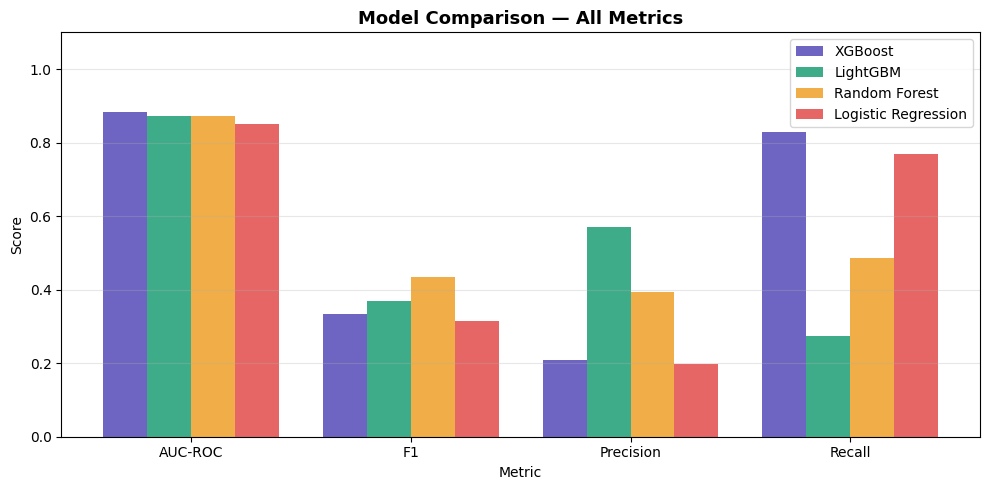

In [11]:
# ── Bar chart comparison ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

metrics = ['AUC-ROC', 'F1', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.2
colors = ['#534AB7', '#1D9E75', '#EF9F27', '#E24B4A']

for i, (_, row) in enumerate(results.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics],
           width, label=row['Model'], color=colors[i], alpha=0.85)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

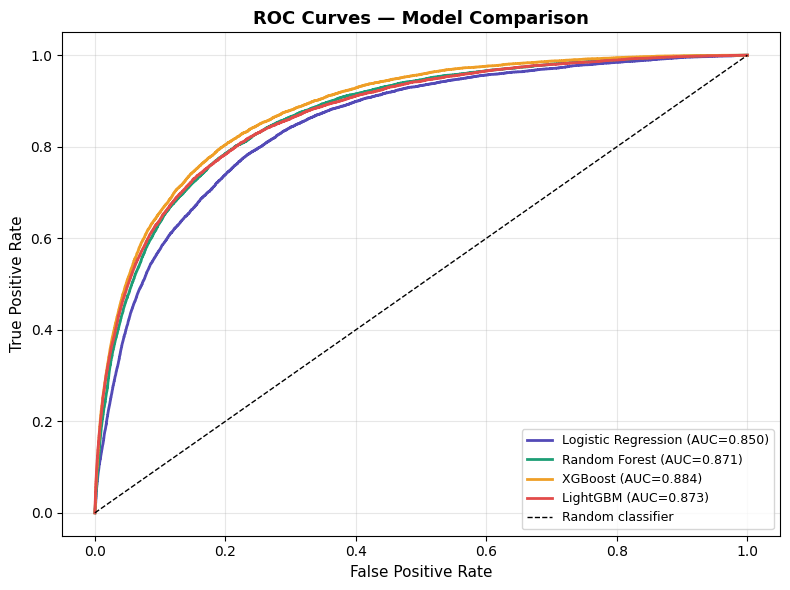

In [12]:
# ── ROC Curves ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

model_results = [
    ('Logistic Regression', lr_proba, '#534AB7'),
    ('Random Forest', rf_proba, '#1D9E75'),
    ('XGBoost', xgb_proba, '#EF9F27'),
    ('LightGBM', lgbm_proba, '#E24B4A')
]

for name, proba, color in model_results:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})',
            color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/04_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

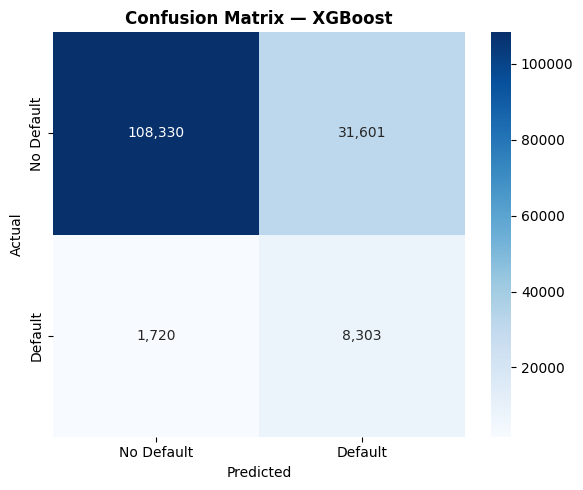


Best model: XGBoost
TN: 108,330  FP: 31,601
FN: 1,720  TP: 8,303


In [13]:
# ── Confusion matrix for best model ───────────────────────────
# We'll use the best model based on AUC-ROC from results table
best_model_name = results.iloc[0]['Model']
best_pred = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred,
    'XGBoost': xgb_pred,
    'LightGBM': lgbm_pred
}[best_model_name]

cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nBest model: {best_model_name}')
print(f'TN: {cm[0,0]:,}  FP: {cm[0,1]:,}')
print(f'FN: {cm[1,0]:,}  TP: {cm[1,1]:,}')

## 5. Save Best Model

In [14]:
# ── Save the best model for SHAP explainability ────────────────
import os
os.makedirs('../models', exist_ok=True)

best_model = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb_model,
    'LightGBM': lgbm
}[best_model_name]

joblib.dump(best_model, '../models/best_model.joblib')
joblib.dump(FEATURES, '../models/feature_names.joblib')

print(f'✅ Best model saved: {best_model_name}')
print(f'   File: ../models/best_model.joblib')
print(f'   Features: ../models/feature_names.joblib')
print(f'\nProceed to Notebook 05 for SHAP explainability.')

✅ Best model saved: XGBoost
   File: ../models/best_model.joblib
   Features: ../models/feature_names.joblib

Proceed to Notebook 05 for SHAP explainability.


## 6. Summary

| Model | AUC-ROC | F1 | Precision | Recall |
|---|---|---|---|---|
| Logistic Regression | 0.8500 | 0.3160 | 0.1990 | 0.7677 |
| Random Forest | 0.8714 | 0.4356 | 0.3949 | 0.4855 |
| XGBoost | **0.8842** | 0.3326 | 0.2081 | **0.8284** |
| LightGBM | 0.8727 | 0.3692 | 0.5710 | 0.2728 |

**Best model**: XGBoost  
**Why**: XGBoost achieved the highest AUC-ROC (0.8842) and the best Recall (0.8284), meaning it correctly identified 82.8% of all actual defaulters. In credit risk, missing a defaulter (false negative) is more costly than a false alarm, so high recall is the priority. Only 1,720 defaulters were missed out of 10,023.

**Next steps (Week 6 — Explainability)**:
- Load XGBoost model and run SHAP analysis
- Generate summary plot, waterfall plot, force plot
- Translate feature importance findings into business language